# Twitter US Airline EDA & Sentiment Analysis -- Semester 2, KM6312, Firefox, Group Project

## Env Import

In [40]:
from argparse import Namespace
import pandas as pd
import re
import emoji
import contractions # could only pip installed
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline

## Raw Data Summary

In [41]:
raw_file_path = './src/tweets.csv'
df = pd.read_csv(raw_file_path)

print("Raw Dataset:", df.shape[0])

print(df.columns.tolist())
print(df.dtypes)

Raw Dataset: 14640
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']
tweet_id                          int64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                       str
dtype: object


In [42]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


### Remove Irrelevant Columns

In [43]:
columns_to_drop = ['tweet_id','airline_sentiment_gold','negativereason_gold','tweet_location','tweet_coord', 'user_timezone']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=False)
df['tweet_created'] = df['tweet_created'].dt.tz_localize(None)

adjusted_file_path = "./src/tweets_adjusted.csv"
df.to_csv(adjusted_file_path, index=False)

print(f"Selected columns deleted and file saved to: {adjusted_file_path}")

Selected columns deleted and file saved to: ./src/tweets_adjusted.csv


### Data Pre-processing

In [44]:
def clean_text(text):
    text = contractions.fix(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"<.*?>", " ", text)                  # remove HTML tags
    emojis_in_text = ''.join(c for c in text if emoji.is_emoji(c))  # replace emojis
    text = re.sub(r"[^a-zA-Z0-9@\s]", " ", text)                   # remove punctuation
    text += ' ' + emojis_in_text                                    # replace emojis back to text
    text = re.sub(r"\s+", " ", text).strip()            # remove extra whitespace
    return text

tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=True)
# preserve_case=False means lowercase when tokenizing;
# reduce_len=True means shorten repeated characters but keep its emotional differences;
# strip_handles=True means remove Twitter handles, eg: @user123, @Delta.
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {'no', 'not', 'nor'}

# Report: lemmatize_tokens is forced to set as false, because it will lemmatize was as wa, polluting wordcloud and model sets.
def tokenize(text, lemmatize_tokens=False, remove_stopwords=True):
    tokens = tokenizer.tokenize(text)
    if lemmatize_tokens:
        tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    if remove_stopwords:
        tokens = [tok for tok in tokens if tok not in stop_words]
    return tokens

df['clean_text'] = df['text'].apply(clean_text)
df['tokens'] = df['clean_text'].apply(tokenize)
df['tokens'] = df['tokens'].apply(lambda tokens: [tok for tok in tokens if tok != 'amp'])
df['processed_text'] = df['tokens'].apply(lambda x: ' '.join(x))

before = len(df)
df = df[df['processed_text'].notna() & (df['processed_text'] != '')].reset_index(drop=True)
df = df.drop_duplicates(subset=['processed_text']).reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicate records. Remaining: {after}")

cleaned_file_path = "./src/tweets_cleaned.csv"
df.to_csv(cleaned_file_path, index=False)

print(f"Cleaned tweets saved to: {cleaned_file_path}")


Removed 540 duplicate records. Remaining: 14100
Cleaned tweets saved to: ./src/tweets_cleaned.csv


## Part 1: Data Structure & EDA

### Pre-Processed Data

In [45]:
cleaned_file_path = "./src/tweets_cleaned.csv"
df = pd.read_csv(cleaned_file_path)

print("Cleaned Dataset:", df.shape[0])

print(df.columns.tolist())
print(df.dtypes)

Cleaned Dataset: 14100
['airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'name', 'retweet_count', 'text', 'tweet_created', 'clean_text', 'tokens', 'processed_text']
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
name                                str
retweet_count                     int64
text                                str
tweet_created                       str
clean_text                          str
tokens                              str
processed_text                      str
dtype: object


In [46]:
df.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,clean_text,tokens,processed_text
0,neutral,1.0000,NaN,NaN,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52,@VirginAmerica What @dhepburn said,['said'],said
1,positive,0.3486,NaN,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59,@VirginAmerica plus you have added commercials...,"['plus', 'added', 'commercials', 'experience',...",plus added commercials experience tacky
2,neutral,0.6837,NaN,NaN,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48,@VirginAmerica I did not today Must mean I nee...,"['not', 'today', 'must', 'mean', 'need', 'take...",not today must mean need take another trip
3,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36,@VirginAmerica it is really aggressive to blas...,"['really', 'aggressive', 'blast', 'obnoxious',...",really aggressive blast obnoxious entertainmen...
4,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45,@VirginAmerica and it is a really big bad thin...,"['really', 'big', 'bad', 'thing']",really big bad thing


### Exploratory Data Analysis

#### Pre-Processed Text Length Statistics

In [47]:
df['processed_text_length'] = df['processed_text'].apply(lambda x: len(str(x).split()))
print("\nPre-Processed Text Length Statistics:\n")
print(df['processed_text_length'].describe())

print("Longest Text:\n", df.loc[df['processed_text_length'].idxmax(), 'processed_text'])
print("Shortest Text:\n", df.loc[df['processed_text_length'].idxmin(), 'processed_text'])


Pre-Processed Text Length Statistics:

count    14100.000000
mean         9.662766
std          4.103003
min          1.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         27.000000
Name: processed_text_length, dtype: float64
Longest Text:
 mia ewr 384 excellent crew ewr iad 3589 no crew load bags waiting w door open freezing 20 mins past departure 😄 😄 😄 😡 😡 😡
Shortest Text:
 said


#### Pre-Processed Text Length Distribution

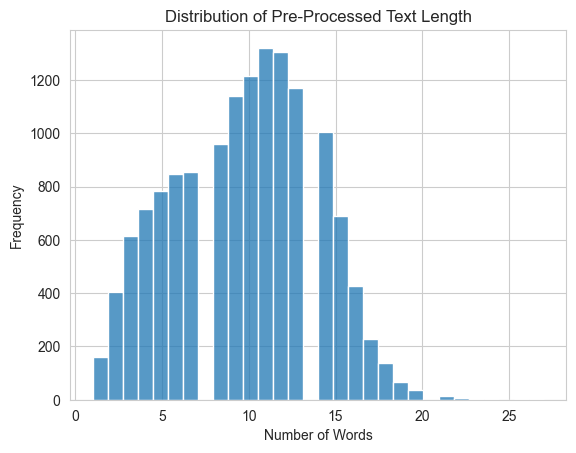

In [48]:
plt.figure()
sns.histplot(df['processed_text_length'], bins=30)
plt.title("Distribution of Pre-Processed Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

#### Sentiment Distribution of Pre-Processed Records

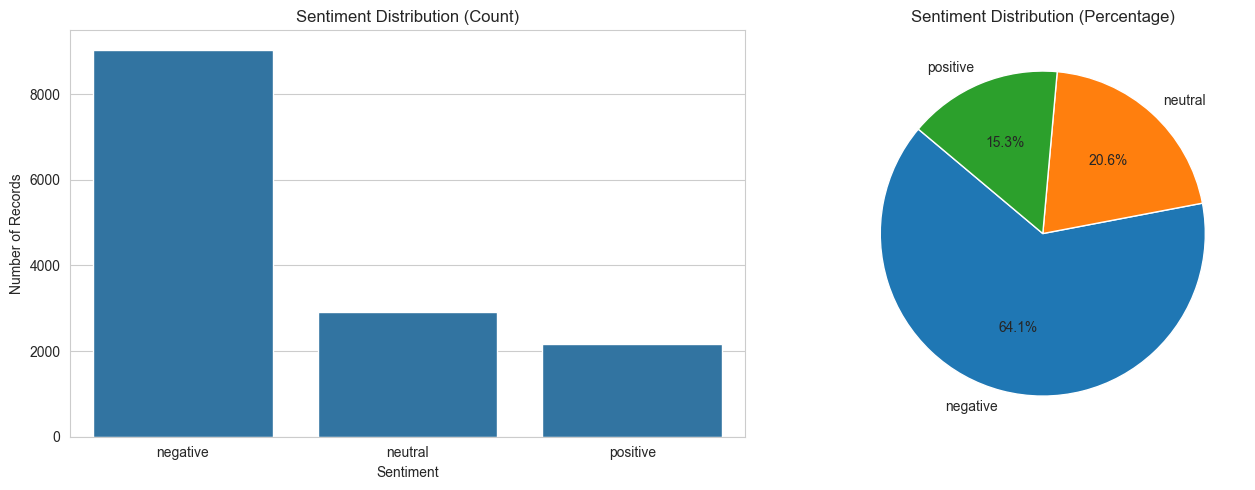

In [49]:
sentiment_counts = df['airline_sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, ax=axes[0])
axes[0].set_title("Sentiment Distribution (Count)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Records")

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title("Sentiment Distribution (Percentage)")

plt.tight_layout()
plt.show()

#### Wordcloud for each Sentiment

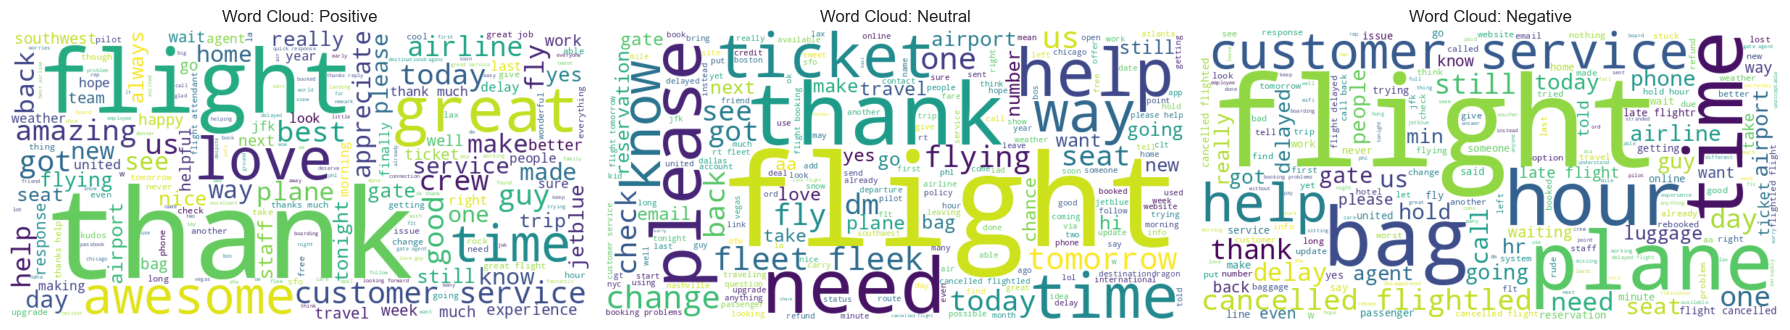

In [50]:
# Wordcloud has a stop-word list within the function, preventing words like no, not, nor from appearing in the wordcloud.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sentiments = ['positive', 'neutral', 'negative']

for i, sentiment in enumerate(sentiments):
    text_data = df[df['airline_sentiment'] == sentiment]['processed_text']
    combined_text = " ".join(text_data.astype(str))
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(combined_text)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"Word Cloud: {sentiment.capitalize()}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### Sentiment Distribution by Airline

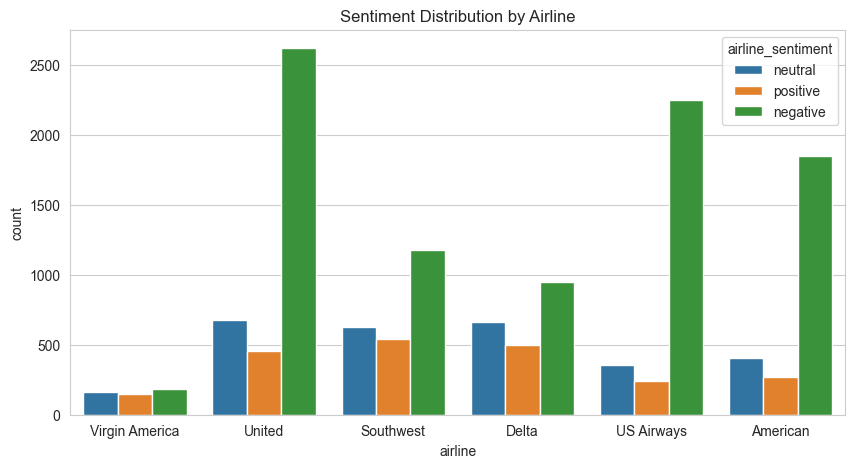

In [51]:
plt.figure(figsize=(10,5))
sns.countplot(x='airline', hue='airline_sentiment', data=df)
plt.title("Sentiment Distribution by Airline")
plt.show()

#### Negative Reasons for Tweets with Negative Sentiment

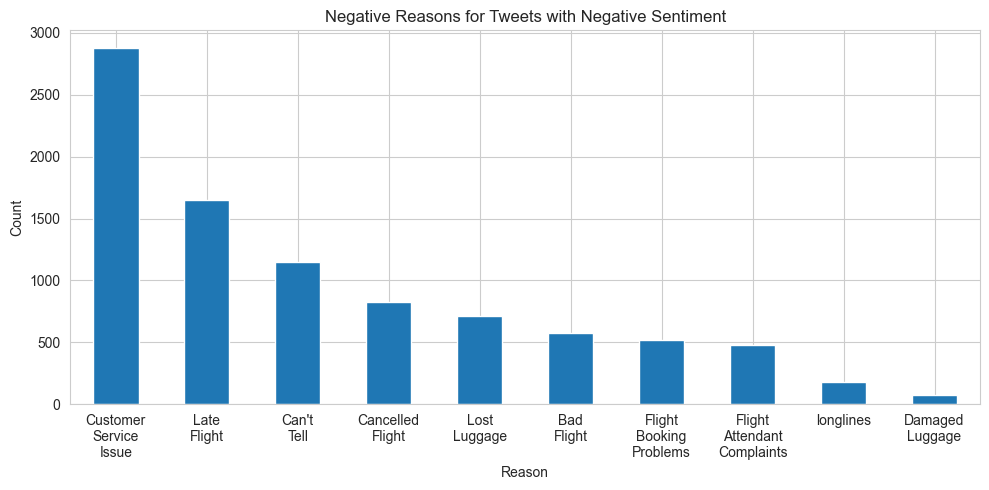

In [52]:
counts = df['negativereason'].value_counts().head(10)
labels = ['\n'.join(label.split()) for label in counts.index]

plt.figure(figsize=(10,5))
counts.plot(kind='bar')

plt.title("Negative Reasons for Tweets with Negative Sentiment")
plt.xlabel("Reason")
plt.ylabel("Count")

plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, ha='center')

plt.tight_layout()
plt.show()